In [4]:
import pandas as pd
data = pd.read_csv('C:/myFiles/Teaching/AML1/4_Linear_Regression/earning.csv')
from sklearn.model_selection import train_test_split
train = data.sample(frac=0.7,random_state=617)
test = data.drop(train.index, axis = 0)

In [53]:
from statsmodels.formula.api import ols
train.gender = pd.Categorical(train.gender,categories = ['male','female'], ordered=True)
reg = ols('earn~age+gender+height+weight+ethnicity+education+age*gender', data = train)

model1 = reg.fit()
model1.params
model1.summary()
#train.columns

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     34.42
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.73e-54
Time:                        22:25:43   Log-Likelihood:                -15261.
No. Observations:                1250   AIC:                         3.054e+04
Df Residuals:                    1240   BIC:                         3.059e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              -7.89e+04   3.76e+04     -2.099      0.036   -1.53e+05   -5170.262
gender[T.female]      -1.875e+04   8184.799     -2.291      0.022   -3.48e+04   -2691.407
ethnicity[T.Asian]    -5619.8844   1.18e+04     -0.474      0.635   -2.89e+04    1.76e+04
ethnicity[T.Hispanic] -1773.0087   7156.905     -0.248      0.804   -1.58e+04    1.23e+04
ethnicity[T.White]     4913.8347   4716.447      1.042      0.298   -4339.263    1.42e+04
age                     555.7741    130.898      4.246      0.000     298.969     812.579
age:gender[T.female]   -264.1106    164.246     -1.608      0.108    -586.341      58.120
height                  528.8019    551.679      0.959      0.338    -553.526    1611.129
weight                   -7.7978     48.880     -0.160      0.873    -103.693      88.098
education              6431.2840    547.589     11.745      0.000    5356.981    7505.587
==============================================================================
Omnibus:                     1584.606   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           439750.019
Skew:                           6.385   Prob(JB):                         0.00
Kurtosis:                      93.995   Cond. No.                     4.97e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.97e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [54]:
pred = model1.predict()
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
def metrics(true, pred):
    rmse = root_mean_squared_error(true, pred)
    mse = mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    result = pd.DataFrame({'metric':['rmse','mse','r2'],
                           'score': [rmse, mse, r2]}).set_index('metric')
    return(result)
metrics(train.earn,pred)
root_mean_squared_error(train.earn, pred)

48518.31412707233

In [58]:
reg = ols('earn~age', data = train)
model = reg.fit()
model.predict({'const':[1,1],'age':[30,31]})

0    46566.248726
1    46754.354577
dtype: float64

In [60]:
model.predict({'age':[30,31]}).diff()

0           NaN
1    188.105851
dtype: float64

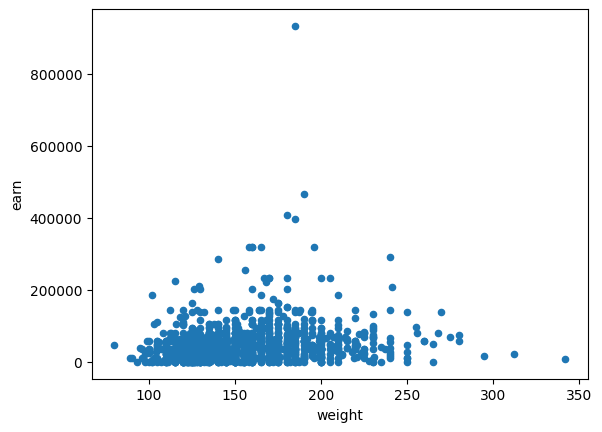

In [65]:
train.plot(x = 'weight', y = 'earn', kind='scatter');

<Axes: ylabel='gender'>

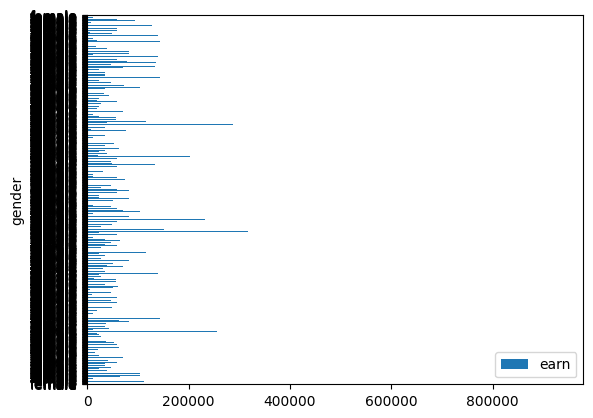

In [74]:
train.plot(x='gender', y = 'earn', kind = 'barh')

In [69]:
train.gender = train.gender.astype(str)
reg = ols('earn~gender', data = train)
model = reg.fit()
model.params

Intercept         36426.621309
gender[T.male]    33727.977417
dtype: float64

In [71]:
model.predict({'gender':['male','female']})

0    70154.598726
1    36426.621309
dtype: float64

In [72]:
model.predict()

array([70154.59872611, 70154.59872611, 36426.62130937, ...,
       36426.62130937, 36426.62130937, 70154.59872611], shape=(1250,))

In [75]:
model.pvalues

Intercept         4.639869e-75
gender[T.male]    1.190390e-27
dtype: float64